## Business Understanding
This project analyzes the Stack Overflow Developer Survey 2023 to answer three questions:
1. Does professional experience affect salary, and by how much?
2. Does education level significantly impact developer earnings?
3. Do AI tool users earn more than non-users?

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [ ]:
df = pd.read_csv("data/results.csv")

print("Shape:", df.shape)
df.head()

الشكل: (65437, 114)


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


## Data Understanding
The dataset contains 65,437 developers and 114 columns. We examine missing values, data types, and key distributions before selecting relevant features.

In [ ]:
# ===========================
# Step 2: Data Understanding
# ===========================


df = pd.read_csv("data/results.csv")

# 2.1 General Overview
print("Number of participants:", df.shape[0])
print("Number of columns:", df.shape[1])

عدد المشاركين: 65437
عدد الأعمدة: 114


In [ ]:
df = pd.read_csv("data/schema.csv")

print("Shape:", df.shape)
df.head()

الشكل: (87, 6)


,qid,qname,question,force_resp,type,selector
0,QID2,MainBranch,Which of the following options best describes ...,True,MC,SAVR
1,QID127,Age,What is your age?*,True,MC,SAVR
2,QID296,Employment,Which of the following best describes your cur...,True,MC,MAVR
3,QID308,RemoteWork,Which best describes your current work situation?,False,MC,SAVR
4,QID341,Check,Just checking to make sure you are paying atte...,True,MC,SAVR


In [ ]:
df = pd.read_csv("data/schema.csv")

# 2.1 General Overview
print("Number of participants:", df.shape[0])
print("Number of columns:", df.shape[1])

عدد المشاركين: 87
عدد الأعمدة: 6


In [ ]:
# Load the main dataset
df = pd.read_csv("data/results.csv")

# Display all column names
for col in df.columns:
    print(col)

ResponseId
MainBranch
Age
Employment
RemoteWork
Check
CodingActivities
EdLevel
LearnCode
LearnCodeOnline
TechDoc
YearsCode
YearsCodePro
DevType
OrgSize
PurchaseInfluence
BuyNewTool
BuildvsBuy
TechEndorse
Country
Currency
CompTotal
LanguageHaveWorkedWith
LanguageWantToWorkWith
LanguageAdmired
DatabaseHaveWorkedWith
DatabaseWantToWorkWith
DatabaseAdmired
PlatformHaveWorkedWith
PlatformWantToWorkWith
PlatformAdmired
WebframeHaveWorkedWith
WebframeWantToWorkWith
WebframeAdmired
EmbeddedHaveWorkedWith
EmbeddedWantToWorkWith
EmbeddedAdmired
MiscTechHaveWorkedWith
MiscTechWantToWorkWith
MiscTechAdmired
ToolsTechHaveWorkedWith
ToolsTechWantToWorkWith
ToolsTechAdmired
NEWCollabToolsHaveWorkedWith
NEWCollabToolsWantToWorkWith
NEWCollabToolsAdmired
OpSysPersonal use
OpSysProfessional use
OfficeStackAsyncHaveWorkedWith
OfficeStackAsyncWantToWorkWith
OfficeStackAsyncAdmired
OfficeStackSyncHaveWorkedWith
OfficeStackSyncWantToWorkWith
OfficeStackSyncAdmired
AISearchDevHaveWorkedWith
AISearchDevWantTo

In [ ]:
# Inspect column types and missing value counts
summary = pd.DataFrame({
    'Type': df.dtypes,
    'Missing Values': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(1),
    'Unique Values': df.nunique()
})

summary

,النوع,القيم المفقودة,نسبة المفقودة %,القيم الفريدة
ResponseId,int64,0,0.0,65437
MainBranch,str,0,0.0,5
Age,str,0,0.0,8
Employment,str,0,0.0,110
RemoteWork,str,10631,16.2,3
...,...,...,...,...
JobSatPoints_11,float64,35992,55.0,79
SurveyLength,str,9255,14.1,3
SurveyEase,str,9199,14.1,3
ConvertedCompYearly,float64,42002,64.2,6113


In [ ]:
# Detailed column inspection
pd.set_option('display.max_rows', 200)

summary = pd.DataFrame({
    'Type': df.dtypes,
    'Missing Values': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(1),
    'Unique Values': df.nunique()
})

summary


,النوع,القيم المفقودة,نسبة المفقودة %,القيم الفريدة
ResponseId,int64,0,0.0,65437
MainBranch,str,0,0.0,5
Age,str,0,0.0,8
Employment,str,0,0.0,110
RemoteWork,str,10631,16.2,3
Check,str,0,0.0,1
CodingActivities,str,10971,16.8,118
EdLevel,str,4653,7.1,8
LearnCode,str,4949,7.6,418
LearnCodeOnline,str,16200,24.8,10853


In [ ]:
print(df[['ConvertedCompYearly']].isnull().sum())
print(df[['ConvertedCompYearly']].isnull().mean() * 100)

ConvertedCompYearly    42002
dtype: int64
ConvertedCompYearly    64.186928
dtype: float64


## Data Preparation
We select 9 relevant features, handle missing values via dropna, convert string years to numeric, remove outliers (salary $10k–$250k), apply Label Encoding to ordinal columns (EdLevel, OrgSize), One-Hot Encoding to nominal columns (RemoteWork, AISelect), binary extraction for languages and developer types, and Target Encoding for Country (computed on training set only to prevent data leakage).

In [ ]:
# Final selected columns
final_cols = [
    'ConvertedCompYearly',
    'EdLevel',
    'YearsCode',
    'YearsCodePro',
    'DevType',
    'RemoteWork',
    'OrgSize',
    'AISelect',
    'LanguageHaveWorkedWith'  # ← added
]

df_clean = df[final_cols].copy()

# Extract top 5 languages as binary columns
languages = ['Python', 'JavaScript', 'SQL', 'Java', 'TypeScript']

for lang in languages:
    col_name = f'knows_{lang.lower()}'
    df_clean[col_name] = df_clean['LanguageHaveWorkedWith'].str.contains(lang, na=False).astype(int)

# Drop the original column after extraction
df_clean = df_clean.drop(columns=['LanguageHaveWorkedWith'])

# Drop rows without salary
df_clean = df_clean.dropna(subset=['ConvertedCompYearly'])

print("Final shape:", df_clean.shape)
print("\nMissing values:")
print(df_clean.isnull().sum())

الشكل النهائي: (23435, 13)

القيم المفقودة:
ConvertedCompYearly     0
EdLevel                 0
YearsCode              47
YearsCodePro           90
DevType                32
RemoteWork              8
OrgSize                25
AISelect                0
knows_python            0
knows_javascript        0
knows_sql               0
knows_java              0
knows_typescript        0
dtype: int64


In [ ]:
# Very few missing values — drop the rows
df_clean = df_clean.dropna()

print("Final shape after full cleaning:", df_clean.shape)

الشكل النهائي بعد التنظيف الكامل: (23277, 13)


In [ ]:
def clean_years(value):
    """Convert years column from string to numeric"""
    if value == 'More than 50 years':
        return 50
    elif value == 'Less than 1 year':
        return 0
    else:
        return float(value)

# Apply conversion
df_clean['YearsCode']    = df_clean['YearsCode'].apply(clean_years)
df_clean['YearsCodePro'] = df_clean['YearsCodePro'].apply(clean_years)

# Verify
print(df_clean[['YearsCode', 'YearsCodePro']].dtypes)
print(df_clean[['YearsCode', 'YearsCodePro']].describe())

YearsCode       float64
YearsCodePro    float64
dtype: object
          YearsCode  YearsCodePro
count  23277.000000  23277.000000
mean      15.085020     10.221377
std        9.881278      8.627396
min        0.000000      0.000000
25%        8.000000      4.000000
50%       12.000000      8.000000
75%       20.000000     14.000000
max       50.000000     50.000000


count    2.327700e+04
mean     8.625287e+04
std      1.871223e+05
min      1.000000e+00
25%      3.300000e+04
50%      6.515200e+04
75%      1.080020e+05
max      1.625660e+07
Name: ConvertedCompYearly, dtype: float64


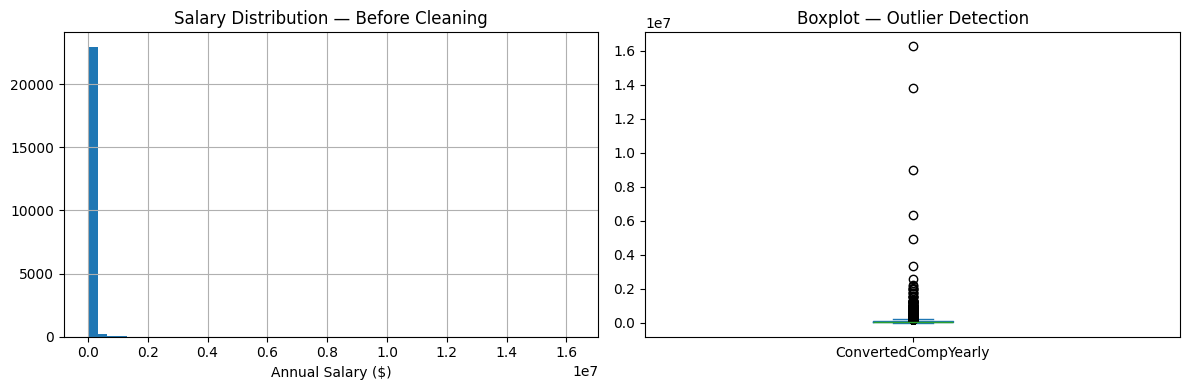

In [ ]:
print(df_clean['ConvertedCompYearly'].describe())

# Plot salary distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Before cleaning
df_clean['ConvertedCompYearly'].hist(bins=50, ax=axes[0])
axes[0].set_title('Salary Distribution — Before Cleaning')
axes[0].set_xlabel('Annual Salary ($)')

# Boxplot to detect outliers
df_clean['ConvertedCompYearly'].plot(kind='box', ax=axes[1])
axes[1].set_title('Boxplot — Outlier Detection')

plt.tight_layout()
plt.show()

الشكل بعد إزالة الشاذات: (20265, 13)


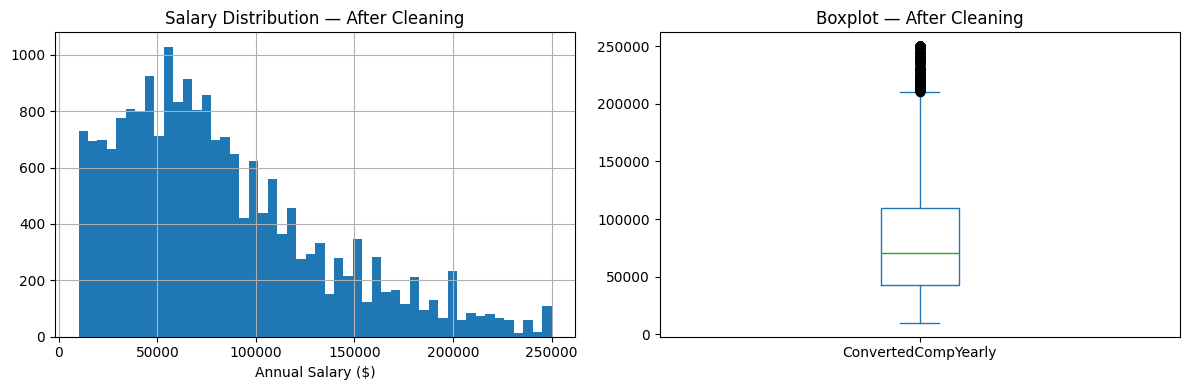

In [ ]:
# Remove salary outliers
df_clean = df_clean[
    (df_clean['ConvertedCompYearly'] >= 10000) &
    (df_clean['ConvertedCompYearly'] <= 250000)
]

print("Shape after removing outliers:", df_clean.shape)

# Re-plot to see the difference
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df_clean['ConvertedCompYearly'].hist(bins=50, ax=axes[0])
axes[0].set_title('Salary Distribution — After Cleaning')
axes[0].set_xlabel('Annual Salary ($)')

df_clean['ConvertedCompYearly'].plot(kind='box', ax=axes[1])
axes[1].set_title('Boxplot — After Cleaning')

plt.tight_layout()
plt.show()

In [ ]:
# Identify text columns
text_cols = df_clean.select_dtypes(include='object').columns
print(text_cols.tolist())

['EdLevel', 'DevType', 'RemoteWork', 'OrgSize', 'AISelect']


/var/folders/2g/t163dscn1b585hnf_dzqf1180000gn/T/ipykernel_70406/1229608725.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = df_clean.select_dtypes(include='object').columns


In [ ]:
print("AISelect — unique values and counts:")
print(df_clean['AISelect'].value_counts())

AISelect — القيم الفريدة وعددها:
AISelect
Yes                        12564
No, and I don't plan to     5085
No, but I plan to soon      2616
Name: count, dtype: int64


In [ ]:
before = df_clean.shape[0]
df_clean = df_clean[df_clean['OrgSize'] != "I don't know"]
after = df_clean.shape[0]
print(f"Removed {before - after} rows")
print(f"Remaining rows: {after}")

تم حذف 0 صف
الصفوف المتبقية: 20265


In [ ]:
edlevel_order = [
    'Primary/elementary school',
    'Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)',
    'Some college/university study without earning a degree',
    'Associate degree (A.A., A.S., etc.)',
    "Bachelor's degree (B.A., B.S., B.Eng., etc.)",
    "Master's degree (M.A., M.S., M.Eng., MBA, etc.)",
    'Professional degree (JD, MD, Ph.D, Ed.D, etc.)',
    'Something else'
]
df_clean['EdLevel'] = df_clean['EdLevel'].map({v: i for i, v in enumerate(edlevel_order)})

orgsize_order = [
    'Just me - I am a freelancer, sole proprietor, etc.',
    '2 to 9 employees',
    '10 to 19 employees',
    '20 to 99 employees',
    '100 to 499 employees',
    '500 to 999 employees',
    '1,000 to 4,999 employees',
    '5,000 to 9,999 employees',
    '10,000 or more employees'
]
df_clean['OrgSize'] = df_clean['OrgSize'].map({v: i for i, v in enumerate(orgsize_order)})

print("✅ Label Encoding done!")
print(df_clean[['EdLevel', 'OrgSize']].head(3))

✅ Label Encoding تم!
     EdLevel  OrgSize
374      6.0      4.0
379      NaN      3.0
385      NaN      0.0


In [ ]:
df_clean = pd.get_dummies(
    df_clean,
    columns=['RemoteWork', 'AISelect'],
    drop_first=True,
    dtype=int
)

print("✅ One-Hot Encoding done!")
print(df_clean.shape)

✅ One-Hot Encoding تم!
(20265, 15)


In [ ]:
top_devtypes = [
    ('Developer, full-stack', 'dev_fullstack'),
    ('Developer, back-end', 'dev_backend'),
    ('Developer, front-end', 'dev_frontend'),
    ('Developer, mobile', 'dev_mobile'),
    ('Data scientist or machine learning specialist', 'dev_datascientist')
]

for devtype, col_name in top_devtypes:
    df_clean[col_name] = df_clean['DevType'].str.contains(devtype, na=False).astype(int)

df_clean = df_clean.drop(columns=['DevType'])

print("✅ DevType done!")
print(f"Final shape: {df_clean.shape}")
print(df_clean.columns.tolist())

✅ DevType تم!
الشكل النهائي: (20265, 19)
['ConvertedCompYearly', 'EdLevel', 'YearsCode', 'YearsCodePro', 'OrgSize', 'knows_python', 'knows_javascript', 'knows_sql', 'knows_java', 'knows_typescript', 'RemoteWork_In-person', 'RemoteWork_Remote', 'AISelect_No, but I plan to soon', 'AISelect_Yes', 'dev_fullstack', 'dev_backend', 'dev_frontend', 'dev_mobile', 'dev_datascientist']


In [ ]:
# Step 1: Restore original EdLevel from df_original
df_clean['EdLevel'] = df_original.loc[df_clean.index, 'EdLevel']

# Step 2: Correct mapping using actual text values
edlevel_order = [
    'Primary/elementary school',
    'Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)',
    'Some college/university study without earning a degree',
    'Associate degree (A.A., A.S., etc.)',
    'Bachelor\u2019s degree (B.A., B.S., B.Eng., etc.)',
    'Master\u2019s degree (M.A., M.S., M.Eng., MBA, etc.)',
    'Professional degree (JD, MD, Ph.D, Ed.D, etc.)',
    'Something else'
]
df_clean['EdLevel'] = df_clean['EdLevel'].map({v: i for i, v in enumerate(edlevel_order)})

print("✅ NaN after fix:", df_clean['EdLevel'].isna().sum())
print(df_clean['EdLevel'].value_counts().sort_index())

✅ NaN بعد التصحيح: 0
EdLevel
0     103
1     983
2    2400
3     642
4    8870
5    6048
6    1040
7     179
Name: count, dtype: int64


In [ ]:
# Inspect actual OrgSize values
print("Actual OrgSize values:")
for val in df_original['OrgSize'].dropna().unique():
    print(repr(val))

القيم الحقيقية في OrgSize:
'100 to 499 employees'
'2 to 9 employees'
'Just me - I am a freelancer, sole proprietor, etc.'
'10 to 19 employees'
'20 to 99 employees'
'5,000 to 9,999 employees'
'1,000 to 4,999 employees'
'I don’t know'
'10,000 or more employees'
'500 to 999 employees'


In [ ]:
# Restore original OrgSize
df_clean['OrgSize'] = df_original.loc[df_clean.index, 'OrgSize']

# Remove freelancers and "I don't know"
before = df_clean.shape[0]

df_clean = df_clean[~df_clean['OrgSize'].str.contains('freelancer|don', na=False)]

after = df_clean.shape[0]
print(f"Removed {before - after} rows")
print(f"Remaining rows: {after}")

# Apply mapping without freelancer
orgsize_order = [
    '2 to 9 employees',
    '10 to 19 employees',
    '20 to 99 employees',
    '100 to 499 employees',
    '500 to 999 employees',
    '1,000 to 4,999 employees',
    '5,000 to 9,999 employees',
    '10,000 or more employees'
]
df_clean['OrgSize'] = df_clean['OrgSize'].map({v: i for i, v in enumerate(orgsize_order)})

print(f"\nRemaining NaN: {df_clean['OrgSize'].isna().sum()}")
print(df_clean['OrgSize'].value_counts().sort_index())
print(f"\nFinal shape: {df_clean.shape}")

تم حذف 1070 صف
الصفوف المتبقية: 19195

NaN المتبقية: 0
OrgSize
0    1754
1    1728
2    4429
3    4041
4    1468
5    2517
6     844
7    2414
Name: count, dtype: int64

الشكل النهائي: (19195, 19)


In [ ]:
# Verify all columns are numeric with no NaN
print("Data types:")
print(df_clean.dtypes)

print(f"\nTotal NaN: {df_clean.isnull().sum().sum()}")
print(f"\nFinal shape: {df_clean.shape}")

أنواع البيانات:
ConvertedCompYearly                float64
EdLevel                              int64
YearsCode                          float64
YearsCodePro                       float64
OrgSize                              int64
knows_python                         int64
knows_javascript                     int64
knows_sql                            int64
knows_java                           int64
knows_typescript                     int64
RemoteWork_In-person                 int64
RemoteWork_Remote                    int64
AISelect_No, but I plan to soon      int64
AISelect_Yes                         int64
dev_fullstack                        int64
dev_backend                          int64
dev_frontend                         int64
dev_mobile                           int64
dev_datascientist                    int64
dtype: object

إجمالي NaN: 0

الشكل النهائي: (19195, 19)


## Results & Visualization
We answer each business question with a dedicated visualization.

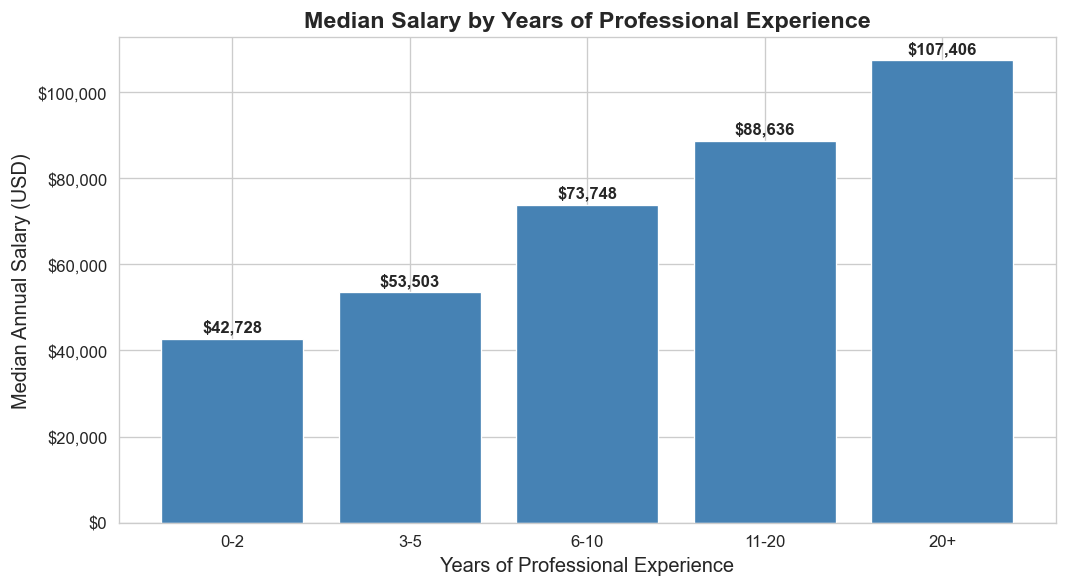

In [ ]:
# Plot settings
plt.rcParams['figure.dpi'] = 120
sns.set_style("whitegrid")

# ===================================================
# Q1: Does professional experience affect salary?
# ===================================================

# Group experience into buckets
bins = [0, 2, 5, 10, 20, 50]
labels = ['0-2', '3-5', '6-10', '11-20', '20+']
df_clean['exp_group'] = pd.cut(df_clean['YearsCodePro'], bins=bins, labels=labels)

# Compute median salary per group
exp_salary = df_clean.groupby('exp_group', observed=True)['ConvertedCompYearly'].median().reset_index()

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(exp_salary['exp_group'], exp_salary['ConvertedCompYearly'], 
              color='steelblue', edgecolor='white', linewidth=0.8)

# Add value labels above each bar
for bar, val in zip(bars, exp_salary['ConvertedCompYearly']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
            f'${val:,.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Median Salary by Years of Professional Experience', fontsize=14, fontweight='bold')
ax.set_xlabel('Years of Professional Experience', fontsize=12)
ax.set_ylabel('Median Annual Salary (USD)', fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

# Drop temporary column
df_clean = df_clean.drop(columns=['exp_group'])

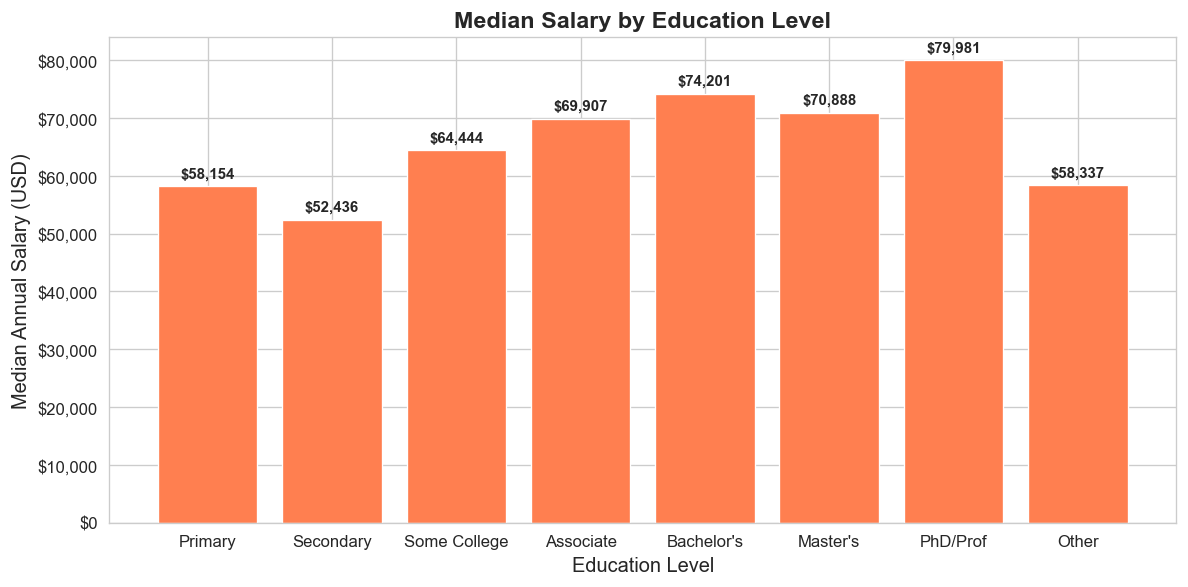

In [ ]:
# ===================================================
# Q2: Does education level affect salary?
# ===================================================

ed_labels = {
    0: 'Primary',
    1: 'Secondary',
    2: 'Some College',
    3: 'Associate',
    4: "Bachelor's",
    5: "Master's",
    6: 'PhD/Prof',
    7: 'Other'
}

ed_salary = df_clean.groupby('EdLevel')['ConvertedCompYearly'].median().reset_index()
ed_salary['label'] = ed_salary['EdLevel'].map(ed_labels)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(ed_salary['label'], ed_salary['ConvertedCompYearly'],
              color='coral', edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, ed_salary['ConvertedCompYearly']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
            f'${val:,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title('Median Salary by Education Level', fontsize=14, fontweight='bold')
ax.set_xlabel('Education Level', fontsize=12)
ax.set_ylabel('Median Annual Salary (USD)', fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

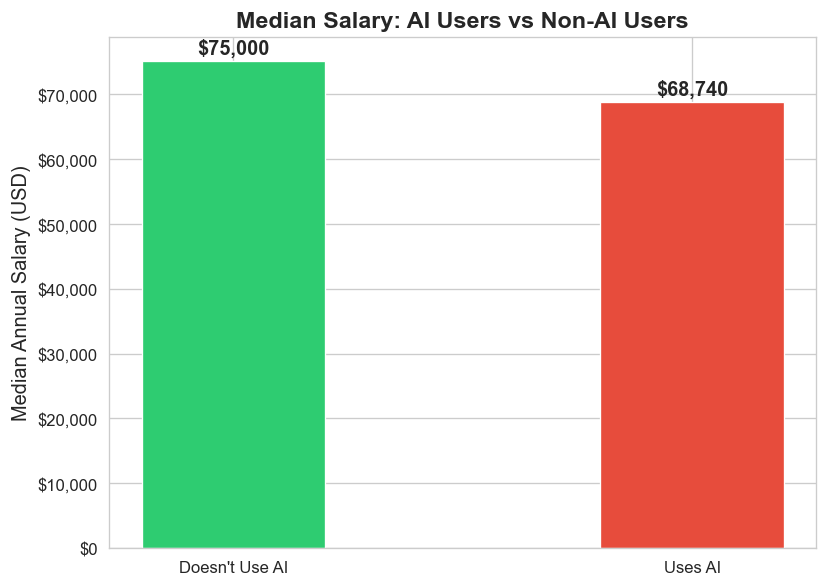

In [ ]:
# ===================================================
# Q3: Do AI tool users earn more than non-users?
# ===================================================

ai_salary = df_clean.groupby('AISelect_Yes')['ConvertedCompYearly'].median().reset_index()
ai_salary['label'] = ai_salary['AISelect_Yes'].map({1: 'Uses AI', 0: "Doesn't Use AI"})

fig, ax = plt.subplots(figsize=(7, 5))
colors = ['#2ecc71', '#e74c3c']
bars = ax.bar(ai_salary['label'], ai_salary['ConvertedCompYearly'],
              color=colors, edgecolor='white', linewidth=0.8, width=0.4)

for bar, val in zip(bars, ai_salary['ConvertedCompYearly']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'${val:,.0f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_title('Median Salary: AI Users vs Non-AI Users', fontsize=14, fontweight='bold')
ax.set_ylabel('Median Annual Salary (USD)', fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

## Modeling
We compare three models: Linear Regression, Random Forest, and Gradient Boosting. We then tune the best model (Gradient Boosting) using RandomizedSearchCV and apply log transformation on the target variable to handle the right-skewed salary distribution.

In [ ]:
# Split features and target
X = df_clean.drop(columns=['ConvertedCompYearly'])
y = df_clean['ConvertedCompYearly']

# Train/Test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape}")
print(f"Test:  {X_test.shape}")

Train: (15356, 18)
Test:  (3839, 18)


In [ ]:
# Define models
models = {
    'Linear Regression':    LinearRegression(),
    'Random Forest':        RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting':    GradientBoostingRegressor(n_estimators=100, random_state=42)
}

# Train and evaluate each model
results = []

for name, model in models.items():
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Evaluate
    r2   = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    results.append({'Model': name, 'R²': round(r2, 4), 'RMSE': round(rmse, 0)})
    print(f"✅ {name} done!")

# Display results
results_df = pd.DataFrame(results).sort_values('R²', ascending=False)
print("\n📊 Model comparison:")
print(results_df.to_string(index=False))

✅ Linear Regression تم!
✅ Random Forest تم!
✅ Gradient Boosting تم!

📊 مقارنة الموديلات:
            Model     R²    RMSE
Gradient Boosting 0.2278 44137.0
Linear Regression 0.1873 45281.0
    Random Forest 0.1496 46318.0


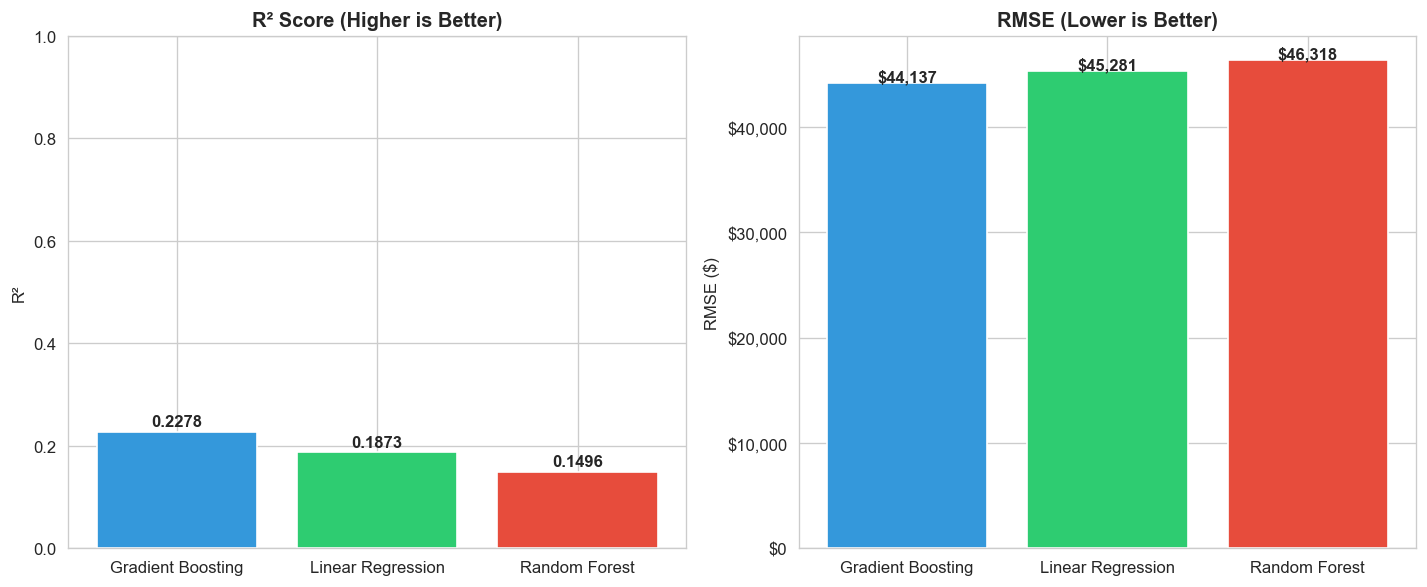

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = ['#3498db', '#2ecc71', '#e74c3c']

# R² chart
axes[0].bar(results_df['Model'], results_df['R²'], color=colors)
axes[0].set_title('R² Score (Higher is Better)', fontweight='bold')
axes[0].set_ylabel('R²')
axes[0].set_ylim(0, 1)
for bar, val in zip(axes[0].patches, results_df['R²']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.4f}', ha='center', fontweight='bold')

# RMSE chart
axes[1].bar(results_df['Model'], results_df['RMSE'], color=colors)
axes[1].set_title('RMSE (Lower is Better)', fontweight='bold')
axes[1].set_ylabel('RMSE ($)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for bar, val in zip(axes[1].patches, results_df['RMSE']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'${val:,.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# Define pipeline with Gradient Boosting
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', GradientBoostingRegressor(random_state=42))
])

# Hyperparameters to search
param_grid = {
    'model__n_estimators':    [100, 200, 300],
    'model__max_depth':       [3, 4, 5],
    'model__learning_rate':   [0.05, 0.1, 0.15],
    'model__min_samples_leaf':[5, 10, 20]
}

# Search for best parameters (5 folds, 20 random iterations)
search = RandomizedSearchCV(
    pipeline,
    param_grid,
    n_iter=20,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

# Best result
best_model = search.best_estimator_
y_pred_best = best_model.predict(X_test)

r2_best   = r2_score(y_test, y_pred_best)
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))

print(f"\n🏆 Best parameters: {search.best_params_}")
print(f"✅ R² after tuning: {r2_best:.4f}")
print(f"✅ RMSE after tuning: ${rmse_best:,.0f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits

🏆 أفضل المعاملات: {'model__n_estimators': 200, 'model__min_samples_leaf': 5, 'model__max_depth': 4, 'model__learning_rate': 0.05}
✅ R²   بعد التحسين: 0.2283
✅ RMSE بعد التحسين: $44,124


In [ ]:
# ============================
# Feature Engineering — new derived features
# ============================

# 1. Ratio of professional experience to total coding years
df_clean['experience_ratio'] = df_clean['YearsCodePro'] / (df_clean['YearsCode'] + 1)

# 2. Total languages known
df_clean['total_languages'] = (
    df_clean['knows_python'] + df_clean['knows_javascript'] +
    df_clean['knows_sql'] + df_clean['knows_java'] + df_clean['knows_typescript']
)

# 3. Senior developer? (10+ years professional experience)
df_clean['is_senior'] = (df_clean['YearsCodePro'] >= 10).astype(int)

# 4. Large company? (1000+ employees)
df_clean['large_company'] = (df_clean['OrgSize'] >= 5).astype(int)

# 5. Interaction term: experience × company size
df_clean['exp_x_orgsize'] = df_clean['YearsCodePro'] * df_clean['OrgSize']

print("✅ Feature Engineering done!")
print(f"New shape: {df_clean.shape}")

✅ Feature Engineering تم!
الشكل الجديد: (19195, 24)


In [ ]:
# ============================
# Add Country — Target Encoding from Training Set only
# (to prevent data leakage)
# ============================

# Restore Country from original data
df_clean['Country'] = df_original.loc[df_clean.index, 'Country']

# Early split before computing Target Encoding
X_new = df_clean.drop(columns=['ConvertedCompYearly'])
y_new = df_clean['ConvertedCompYearly']

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_new, y_new, test_size=0.2, random_state=42
)

# Compute mean salary per country from Training Set only ✅
country_map = X_train2.join(y_train2).groupby('Country')['ConvertedCompYearly'].mean()

X_train2['Country'] = X_train2['Country'].map(country_map)
X_test2['Country']  = X_test2['Country'].map(country_map)

# For countries absent from training set, use global mean
global_mean = y_train2.mean()
X_train2['Country'] = X_train2['Country'].fillna(global_mean)
X_test2['Country']  = X_test2['Country'].fillna(global_mean)

print("✅ Country Target Encoding done!")
print(f"Shape: {X_train2.shape}")

✅ Country Target Encoding تم!
الشكل: (15356, 24)


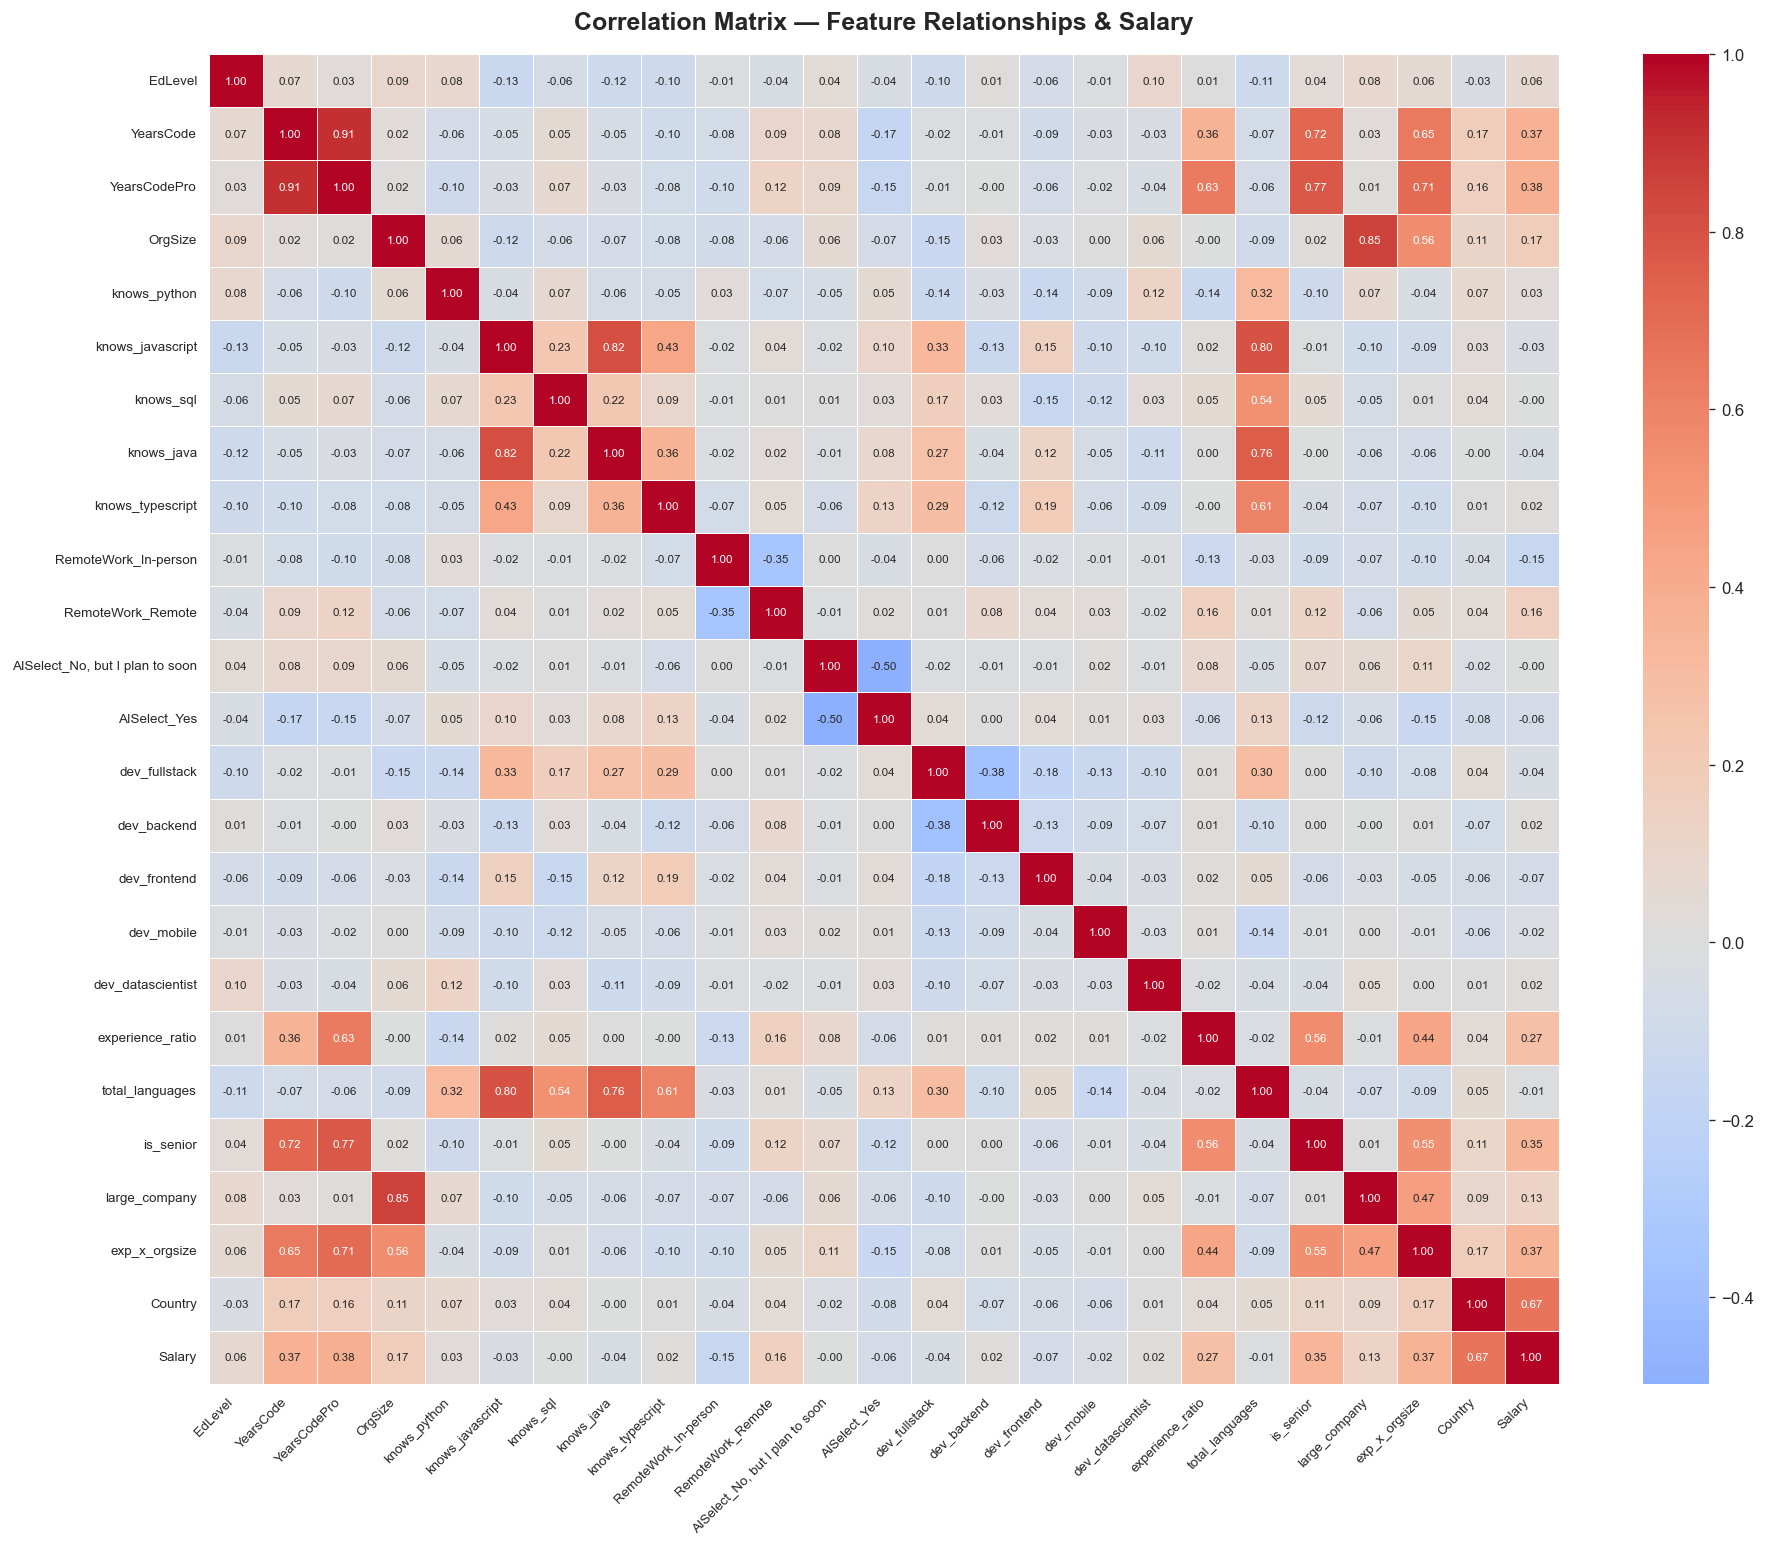


📊 ارتباط كل عمود مع الراتب (مرتب):
Country                            0.668595
YearsCodePro                       0.384545
YearsCode                          0.372266
exp_x_orgsize                      0.366387
is_senior                          0.348582
experience_ratio                   0.274826
OrgSize                            0.173215
RemoteWork_Remote                  0.162859
large_company                      0.129477
EdLevel                            0.064941
knows_python                       0.034580
dev_datascientist                  0.017971
knows_typescript                   0.015710
dev_backend                        0.015615
AISelect_No, but I plan to soon   -0.000774
knows_sql                         -0.001942
total_languages                   -0.007590
dev_mobile                        -0.024662
knows_javascript                  -0.032064
dev_fullstack                     -0.043067
knows_java                        -0.043317
AISelect_Yes                      -0.060

In [ ]:
# ============================
# Correlation Matrix — feature relationships and target
# ============================

# Combine X_train with y for plotting
corr_df = X_train2.copy()
corr_df['Salary'] = y_train2.values

# Compute the correlation matrix
corr_matrix = corr_df.corr()

# Plot
fig, ax = plt.subplots(figsize=(16, 13))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    annot_kws={'size': 7},
    ax=ax
)

ax.set_title('Correlation Matrix — Feature Relationships & Salary', 
             fontsize=15, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

# Top correlations with salary
print("\n📊 Correlation of each feature with salary (sorted):")
salary_corr = corr_matrix['Salary'].drop('Salary').sort_values(ascending=False)
print(salary_corr.to_string())

## Evaluation
The final model achieves R²=0.5678 and RMSE=$33,020. This model explains 56.78% of salary variance. Key drivers are professional experience, company size, and country of residence.

In [ ]:
# ============================
# Drop weak and redundant features
# ============================

cols_to_drop = [
    'YearsCode',          # duplicate of YearsCodePro
    'large_company',      # duplicate of OrgSize
    'total_languages',    # correlation = 0.01
    'knows_sql',          # correlation ≈ 0
    'knows_javascript',   # correlation ≈ 0
    'knows_java',         # correlation ≈ 0
    'EdLevel',            # correlation = 0.06
    'AISelect_Yes',       # negative correlation
    'AISelect_No, but I plan to soon',
    'dev_frontend',
    'dev_mobile',
    'dev_backend',
    'dev_datascientist',
    'RemoteWork_In-person'
]

X_train3 = X_train2.drop(columns=cols_to_drop)
X_test3  = X_test2.drop(columns=cols_to_drop)

print(f"Remaining features ({X_train3.shape[1]}):")
print(X_train3.columns.tolist())

# ============================
# Apply log transformation on target
# (right-skewed distribution)
# ============================


y_train_log = np.log1p(y_train2)
y_test_log  = np.log1p(y_test2)

# ============================
# Final model
# ============================

pipeline3 = Pipeline([
    ('scaler', StandardScaler()),
    ('model', GradientBoostingRegressor(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        min_samples_leaf=5,
        random_state=42
    ))
])

pipeline3.fit(X_train3, y_train_log)
y_pred_log = pipeline3.predict(X_test3)

# Convert back from log to original scale
y_pred_final = np.expm1(y_pred_log)

r2_final   = r2_score(y_test2, y_pred_final)
rmse_final = np.sqrt(mean_squared_error(y_test2, y_pred_final))

print(f"\n✅ Final R²:  {r2_final:.4f}  (was 0.2283)")
print(f"✅ Final RMSE: ${rmse_final:,.0f}  (was $44,124)")
print(f"\n📈 R² improvement: {(r2_final - 0.2283)*100:+.2f}%")

العواميد المتبقية (10):
['YearsCodePro', 'OrgSize', 'knows_python', 'knows_typescript', 'RemoteWork_Remote', 'dev_fullstack', 'experience_ratio', 'is_senior', 'exp_x_orgsize', 'Country']

✅ R²   النهائي:  0.5678  (كان 0.2283)
✅ RMSE النهائي: $33,020  (كان $44,124)

📈 تحسن R²: +33.95%


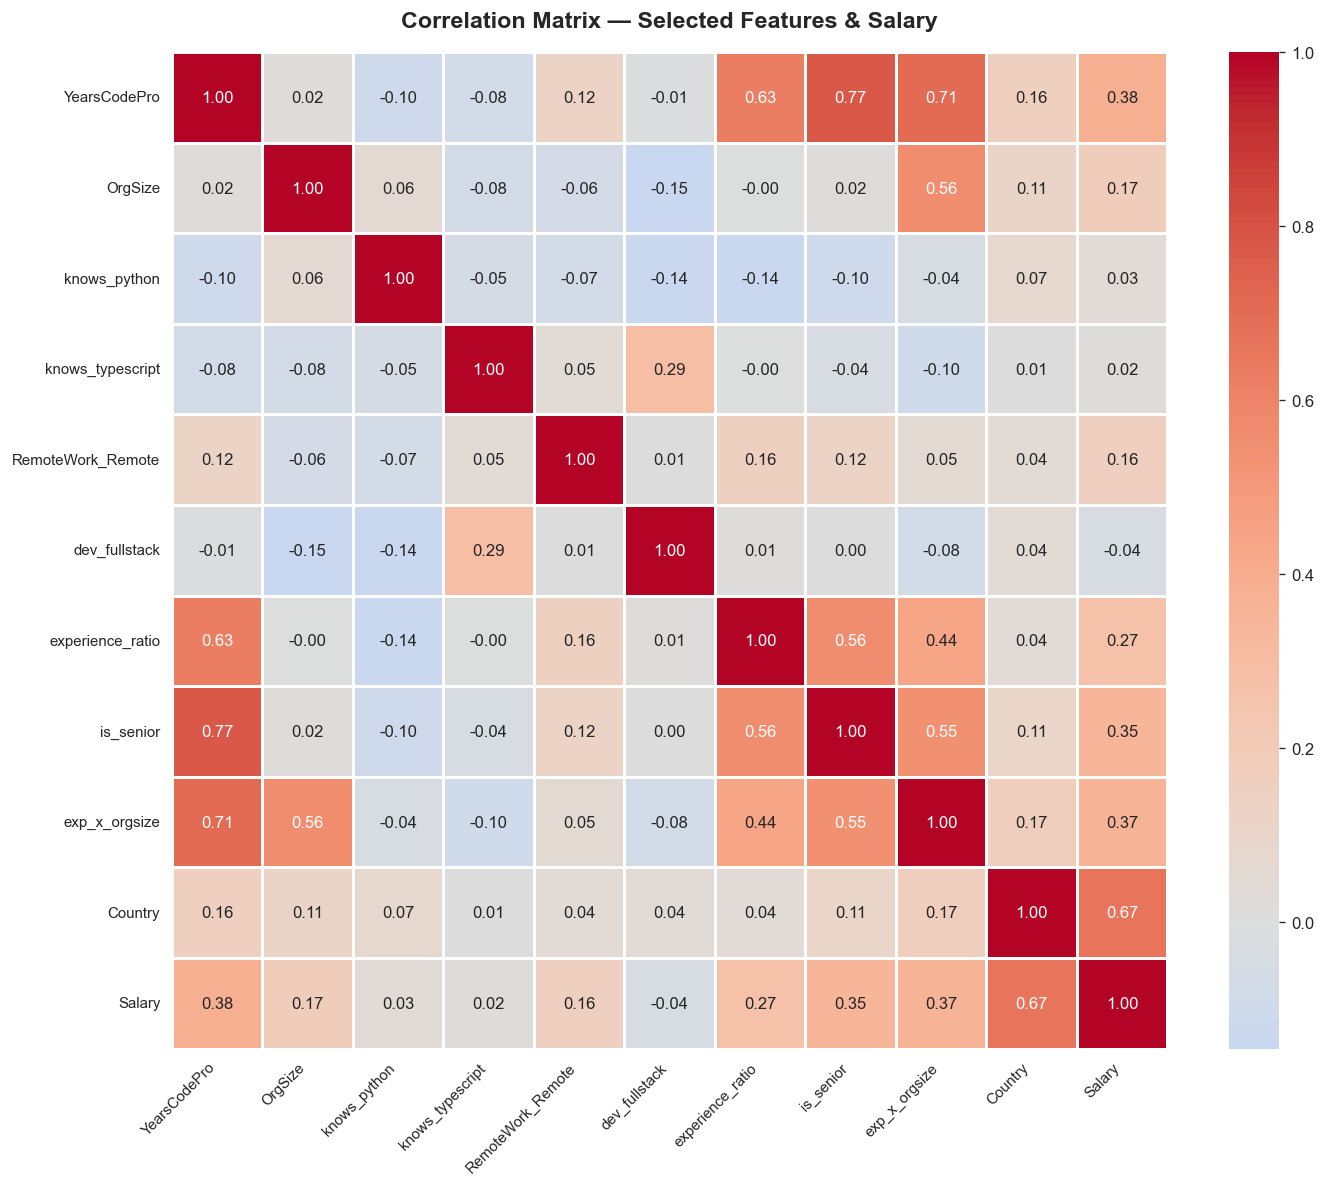


📊 ارتباط كل عمود بالراتب:
Country                   +0.669  █████████████
YearsCodePro              +0.385  ███████
exp_x_orgsize             +0.366  ███████
is_senior                 +0.349  ██████
experience_ratio          +0.275  █████
OrgSize                   +0.173  ███
RemoteWork_Remote         +0.163  ███
knows_python              +0.035  
knows_typescript          +0.016  
dev_fullstack             -0.043  


In [ ]:
# ============================
# Correlation Heatmap — selected features vs salary
# ============================

# Combine X_train3 with salary
corr_df = X_train3.copy()
corr_df['Salary'] = y_train2.values

# Compute the correlation
corr_matrix = corr_df.corr()

# Plot
fig, ax = plt.subplots(figsize=(12, 10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.8,
    annot_kws={'size': 10},
    ax=ax
)

ax.set_title('Correlation Matrix — Selected Features & Salary', 
             fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

# Feature correlations with salary (sorted)
print("\n📊 Feature correlations with salary:")
salary_corr = corr_matrix['Salary'].drop('Salary').sort_values(ascending=False)
for col, val in salary_corr.items():
    bar = '█' * int(abs(val) * 20)
    sign = '+' if val > 0 else '-'
    print(f"{col:25} {sign}{abs(val):.3f}  {bar}")